In [40]:
import decoupler as dc
import liana as li
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import session_info

import cellphonedb
from liana.method import cellphonedb

# import liana's rank_aggregate
from liana.mt import rank_aggregate

# Name: cellphonedb
# Version: 5.0.1

# import anndata2ri
# anndata2ri.activate()
# %load_ext rpy2.ipython

In [41]:
# figure settings
sc.settings.set_figure_params(dpi=200, frameon=False)
sc.set_figure_params(dpi=200, facecolor="white")
sc.set_figure_params(figsize=(5, 5))

/tmp/ipykernel_89727/2857476846.py:2: FutureWarning: Use `scanpy.set_figure_params` instead


In [42]:
import os 
print(os.getcwd())

/home/tanasa/Desktop/LIANA


In [43]:
import os

# current directory
print(os.listdir())

# or sorted
print(sorted(os.listdir()))

# with full path
import glob
print(glob.glob("*"))

# only h5ad files
print(glob.glob("*.h5ad"))

# current directory path
print(os.getcwd())

['liana_env_clean', 'LIANA-tutorial.v2.ipynb', 'metalinksdb.db', 'LIANA-tutorial.IFNG.py', 'dotplot_combined.png', 'seurat5_integrated_RPCA.rds', 'kang.h5ad', 'LIANA-tutorial.PBMC.ipynb', 'seurat5_integrated_CCA.rds', 'liana_env', 'omnipathr-log', 'seurat5_integrated_Harmony.rds', '.ipynb_checkpoints', 'dotplot_combined.pdf', 'LIANA-tutorial.IFNG.ipynb', 'LIANA-tutorial.v1.ipynb', 'LGG_LIANA.ipynb']
['.ipynb_checkpoints', 'LGG_LIANA.ipynb', 'LIANA-tutorial.IFNG.ipynb', 'LIANA-tutorial.IFNG.py', 'LIANA-tutorial.PBMC.ipynb', 'LIANA-tutorial.v1.ipynb', 'LIANA-tutorial.v2.ipynb', 'dotplot_combined.pdf', 'dotplot_combined.png', 'kang.h5ad', 'liana_env', 'liana_env_clean', 'metalinksdb.db', 'omnipathr-log', 'seurat5_integrated_CCA.rds', 'seurat5_integrated_Harmony.rds', 'seurat5_integrated_RPCA.rds']
['liana_env_clean', 'LIANA-tutorial.v2.ipynb', 'metalinksdb.db', 'LIANA-tutorial.IFNG.py', 'dotplot_combined.png', 'seurat5_integrated_RPCA.rds', 'kang.h5ad', 'LIANA-tutorial.PBMC.ipynb', 'seura

In [44]:
# https://www.sc-best-practices.org/mechanisms/cell_cell_communication.html

In [45]:
# import liana
import liana as li
# needed for visualization and toy data
import scanpy as sc

In [46]:
# RESOURCES

In [47]:
import liana as li
import pandas as pd

resources = li.resource.show_resources()

summary = []

for r in resources:
    res = li.resource.select_resource(r)
    
    n_total = res.shape[0]
    n_unique = res[['ligand', 'receptor']].drop_duplicates().shape[0]
    
    summary.append({
        'resource': r,
        'total_rows': n_total,
        'unique_interactions': n_unique
    })

df_summary = pd.DataFrame(summary).sort_values('unique_interactions', ascending=False)

df_summary

,resource,total_rows,unique_interactions
7,consensus,4624,4624
15,mouseconsensus,3989,3989
3,cellinker,3700,3700
5,celltalkdb,3392,3392
14,lrdb,3228,3228
12,italk,2566,2566
6,connectomedb2020,2266,2266
2,cellchatdb,1912,1912
16,ramilowski2015,1889,1889
8,embrace,1650,1650


In [48]:
res = li.resource.select_resource('cellphonedb')
res.head()

,ligand,receptor
13007,JAG2,NOTCH1
13008,DLL1,NOTCH1
13009,IGF1,IGF1R
13010,JAG1,NOTCH1
13011,WNT5A,FZD2


In [49]:
# METHODS

In [50]:
li.mt.show_methods()

,Method Name,Magnitude Score,Specificity Score,Reference
0,CellPhoneDB,lr_means,cellphone_pvals,"Efremova, M., Vento-Tormo, M., Teichmann, S.A...."
0,Connectome,expr_prod,scaled_weight,"Raredon, M.S.B., Yang, J., Garritano, J., Wang..."
0,log2FC,None,lr_logfc,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,NATMI,expr_prod,spec_weight,"Hou, R., Denisenko, E., Ong, H.T., Ramilowski,..."
0,SingleCellSignalR,lrscore,None,"Cabello-Aguilar, S., Alame, M., Kon-Sun-Tack, ..."
0,Rank_Aggregate,magnitude_rank,specificity_rank,"Dimitrov, D., Türei, D., Garrido-Rodriguez, M...."
0,Geometric Mean,lr_gmeans,gmean_pvals,CellPhoneDBv2's permutation approach applied t...
0,scSeqComm,inter_score,None,"Baruzzo, G., Cesaro, G., Di Camillo, B. 2022. ..."
0,CellChat,lr_probs,cellchat_pvals,"Jin, S., Guerrero-Juarez, C.F., Zhang, L., Cha..."


In [51]:
# LIANA will by default use the .raw attribute of AnnData. 
# If you wish to use .X set use_raw to False, or specify a layer.

# LIANA will also by default use the ‘consensus’ resource to infer ligand-receptor interactions. 
# This resource was created as a consensus from the resources literature-curated resources in OmniPath, 
# and uses human gene symbols.

In [52]:
adata = sc.datasets.pbmc68k_reduced()

In [53]:
print(adata)

AnnData object with n_obs × n_vars = 700 × 765
    obs: 'bulk_labels', 'n_genes', 'percent_mito', 'n_counts', 'S_score', 'G2M_score', 'phase', 'louvain'
    var: 'n_counts', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [54]:
print(adata.obs.head(3))

                     bulk_labels  n_genes  percent_mito  n_counts   S_score  \
index                                                                         
AAAGCCTGGCTAAC-1  CD14+ Monocyte     1003      0.023856    2557.0 -0.119160   
AAATTCGATGCACA-1       Dendritic     1080      0.027458    2695.0  0.067026   
AACACGTGGTCTTT-1        CD56+ NK     1228      0.016819    3389.0 -0.147977   

                  G2M_score phase louvain  
index                                      
AAAGCCTGGCTAAC-1  -0.816889    G1       1  
AAATTCGATGCACA-1  -0.889498     S       1  
AACACGTGGTCTTT-1  -0.941749    G1       3  


In [55]:
print(adata.obsm)
print(adata.obsm["X_pca"])
print(adata.obsm["X_umap"])

AxisArrays with keys: X_pca, X_umap
[[-7.939618    5.024914    2.9037306  ... -3.228536   -0.60592127
   0.9732133 ]
 [-7.7352414   4.33796     1.4893486  ... -1.8452125  -0.01023911
   0.07135285]
 [ 9.590969    6.409222   -8.308694   ... -1.3177946  -0.61671865
   1.3843659 ]
 ...
 [ 4.928574    1.2381667   0.53577584 ...  0.7577447   0.6433388
   1.4959103 ]
 [ 2.890713   -6.116919    3.9368765  ...  0.8674861   3.6986613
   1.0767299 ]
 [-5.7872367  -5.0758386  -4.112453   ... -1.1315929  -0.4941009
   0.64597267]]
[[ -1.99186255   8.57641706]
 [ -3.24869194   7.99994913]
 [ -3.59310303  -2.22675898]
 ...
 [ -5.98349489  -5.86929568]
 [-12.35074674  -4.4339864 ]
 [  5.90649366  -3.57606702]]


In [56]:
print(adata.var.head(3))

            n_counts     means  dispersions  dispersions_norm  highly_variable
index                                                                         
HES4     1153.387451  0.592365     2.028047          2.771764             True
TNFRSF4   304.358154  0.193332     1.760724          2.746426             True
SSU72    2530.272705  1.019981     1.208284         -0.631160            False


In [57]:
print(adata.varm)
print(adata.varm["PCs"])

AxisArrays with keys: PCs
[[-0.06094132  0.08646941  0.04735867 ... -0.00692825 -0.05472741
  -0.0206429 ]
 [ 0.01867429  0.01403024 -0.00963269 ...  0.02816893 -0.01079524
   0.02559935]
 [        nan         nan         nan ...         nan         nan
          nan]
 ...
 [ 0.01445048  0.0125472  -0.01942673 ... -0.0342745   0.02684127
  -0.07322939]
 [        nan         nan         nan ...         nan         nan
          nan]
 [        nan         nan         nan ...         nan         nan
          nan]]


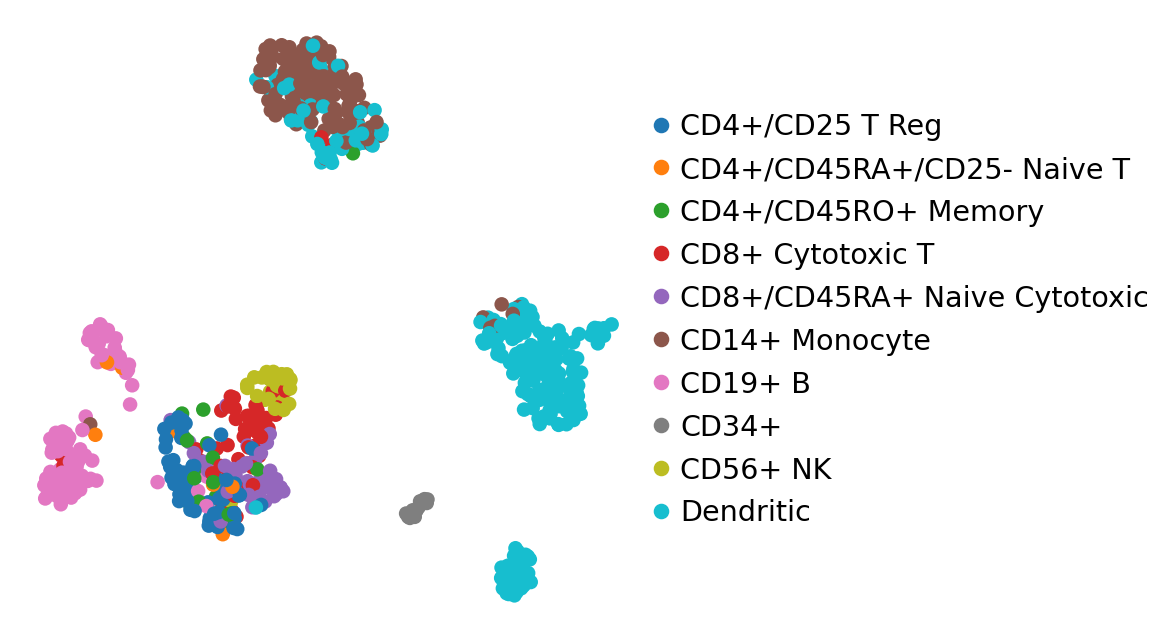

In [58]:
sc.pl.umap(adata, color='bulk_labels', title='', frameon=False)

In [59]:
# adata.raw.X

In [60]:
# check if raw exists first
print(adata.raw)

# access raw matrix
print(adata.raw.X[1:3, 1:3])

# if sparse matrix convert to dense
print(adata.raw.X[1:3, 1:3].toarray())

# raw gene names
print(adata.raw.var_names[:10].tolist())

# raw shape
print("Raw shape:", adata.raw.X.shape)

Raw AnnData with n_obs × n_vars = 700 × 765
<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 2 stored elements and shape (2, 2)>
  Coords	Values
  (0, 1)	1.5499999523162842
  (1, 1)	1.3739999532699585
[[0.    1.55 ]
 [0.    1.374]]
['HES4', 'TNFRSF4', 'SSU72', 'PARK7', 'RBP7', 'SRM', 'MAD2L2', 'AGTRAP', 'TNFRSF1B', 'EFHD2']
Raw shape: (700, 765)


In [61]:
# ?rank_aggregate.__call__

rank_aggregate.describe()

print('''
| Level                      | What happens                                                        |
| -------------------------- | ------------------------------------------------------------------- |
| **Resource (`consensus`)** | curated integration of LR pairs across databases (NOT simple union) |
| **Scoring (RRA)**          | statistical consensus across methods                                |
''')

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.

| Level                      | What happens                                                        |
| -------------------------- | ------------------------------------------------------------------- |
| **Resource (`consensus`)** | curated integration of LR pairs across databases (NOT simple union) |
| **Scoring (RRA)**          | statistical consensus across methods                                |



In [62]:
print("Using Consensus db")

Using Consensus db


In [63]:
import liana as li

res = li.resource.select_resource('consensus')
res.head()

# res.columns
# len(res)

res[['ligand', 'receptor']].drop_duplicates().shape[0]

4624

In [64]:
res = li.resource.select_resource('consensus')

In [65]:
# import all individual methods
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

In [66]:
# run cellphonedb
cellphonedb(adata,
            groupby = 'bulk_labels', 
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name = 'consensus',
            expr_prop = 0.1,
            verbose=True, 
            key_added = 'cpdb_res')

2026-03-27 15:22:10 | [INFO] Using resource `consensus`.
2026-03-27 15:22:10 | [INFO] Using `.raw`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 15:22:10 | [INFO] 0.94 of entities in the resource are missing from the data.


Generating ligand-receptor stats for 700 samples and 43 features


100%|███████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1040.78it/s]


In [67]:
# by default, liana's output is saved in place:
adata.uns['cpdb_res'].head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
482,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.612842,0.421053,Dendritic,CD4+/CD45RO+ Memory,2.575263,0.0
321,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.596125,0.500000,Dendritic,CD4+/CD45RA+/CD25- Naive T,2.566905,0.0
989,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.483977,0.302326,Dendritic,CD14+ Monocyte,2.510830,0.0
651,HLA-DRA,HLA-DRA,4.537684,0.995833,LAG3,LAG3,0.399500,0.240741,Dendritic,CD8+ Cytotoxic T,2.468592,0.0
1392,HLA-DRA,HLA-DRA,4.537684,0.995833,CD4,CD4,0.373671,0.270833,Dendritic,Dendritic,2.455678,0.0


In [68]:
print('''

LIANA / CellPhoneDB Metrics Overview

Expression filtering

*_props

Proportion of cells expressing a given gene within a cell type.

By default, interactions are filtered out if either ligand or receptor is expressed in <10% of cells,
based on the assumption that meaningful cell–cell communication requires sufficient expression within a population.

Expression magnitude

*_means : Mean expression of a gene within a cell type.
* lr_means : Mean expression of the ligand–receptor pair.
Used as a proxy for interaction strength (magnitude) — higher values indicate stronger interactions.

Interaction specificity

* cellphone_pvals

Permutation-based p-values estimating how specific an interaction is between two cell types.
Lower values indicate higher specificity (i.e., less likely to occur by chance).

''')



LIANA / CellPhoneDB Metrics Overview

Expression filtering

*_props

Proportion of cells expressing a given gene within a cell type.

By default, interactions are filtered out if either ligand or receptor is expressed in <10% of cells,
based on the assumption that meaningful cell–cell communication requires sufficient expression within a population.

Expression magnitude

*_means : Mean expression of a gene within a cell type.
* lr_means : Mean expression of the ligand–receptor pair.
Used as a proxy for interaction strength (magnitude) — higher values indicate stronger interactions.

Interaction specificity

* cellphone_pvals

Permutation-based p-values estimating how specific an interaction is between two cell types.
Lower values indicate higher specificity (i.e., less likely to occur by chance).




In [69]:
print(adata.uns.keys())

dict_keys(['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'cpdb_res'])


In [70]:
print("VISUALIZATION:")

VISUALIZATION:


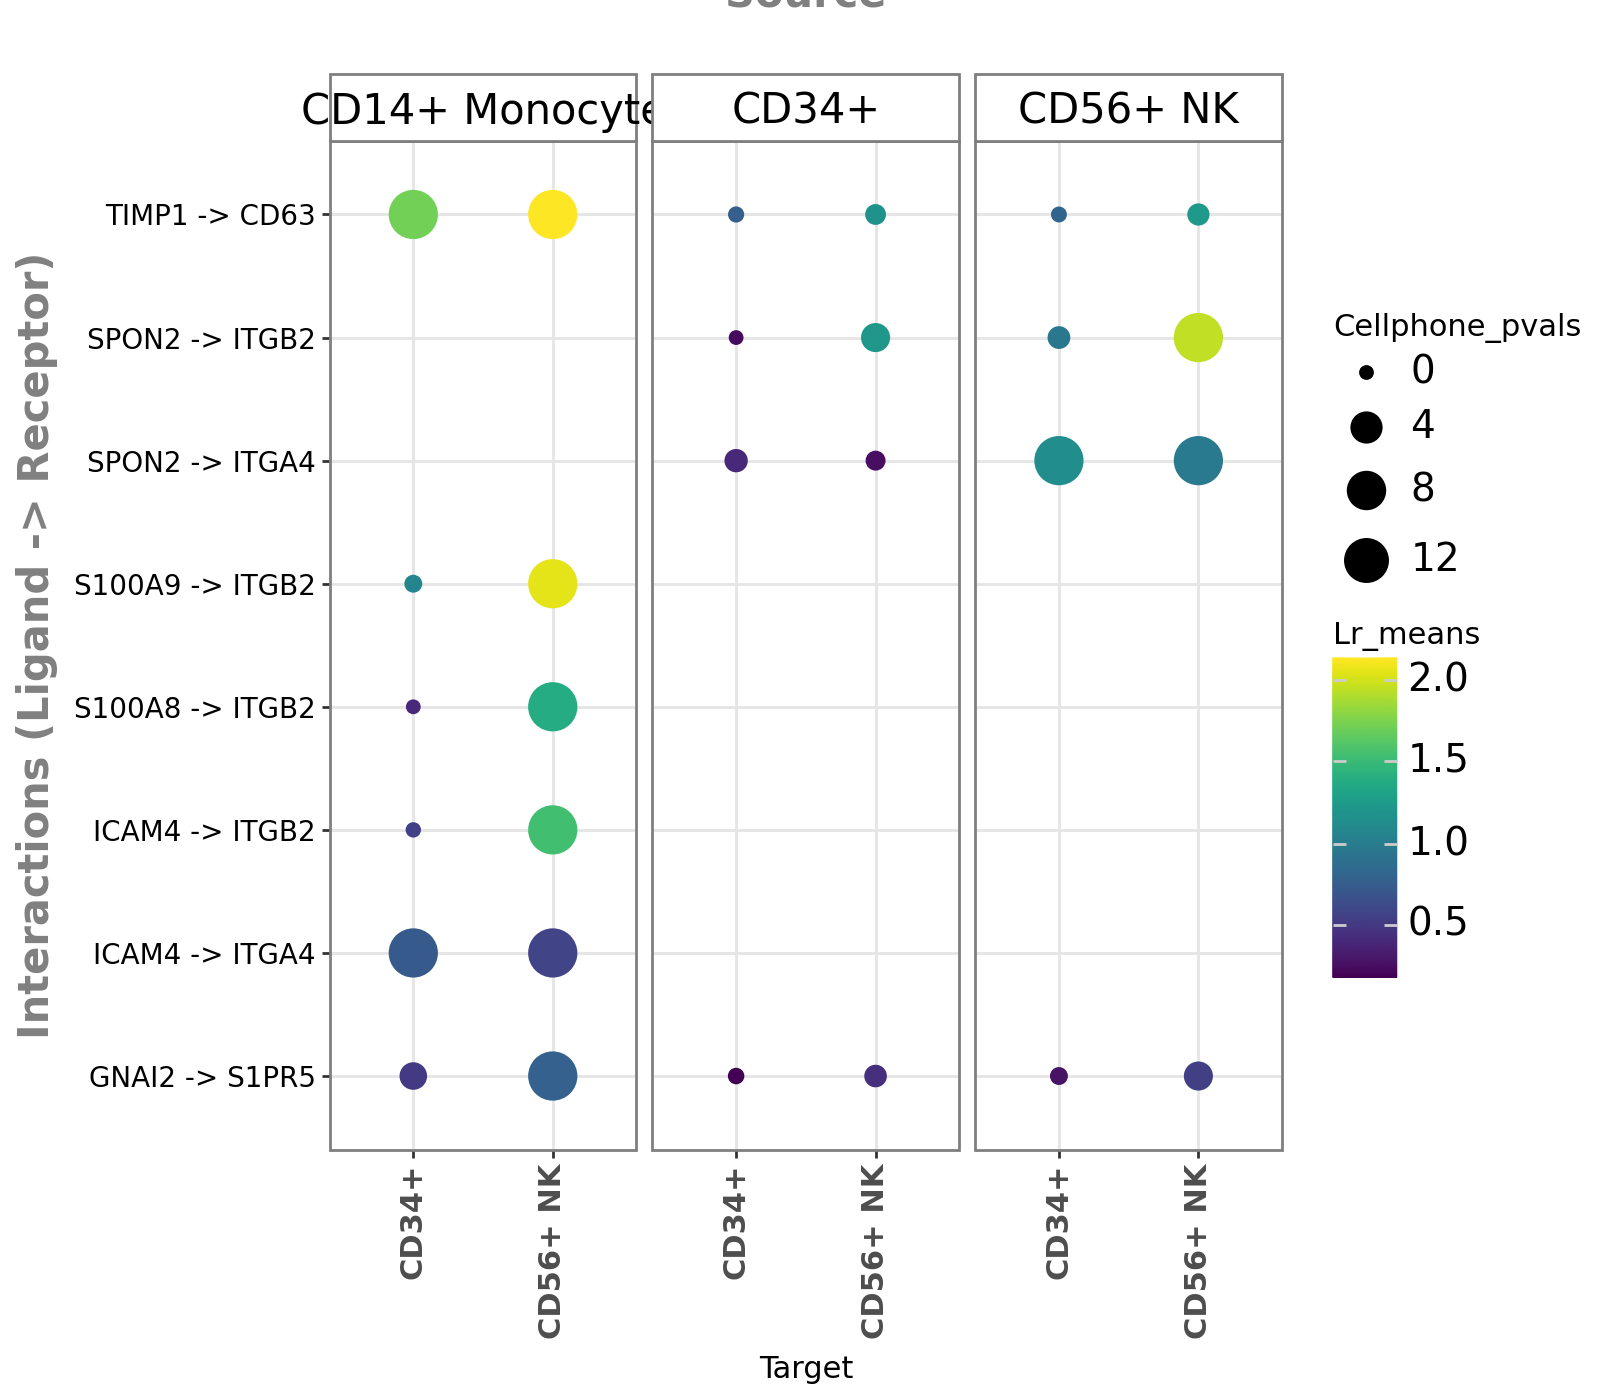

In [71]:
li.pl.dotplot(adata = adata, 
              colour = 'lr_means',
              size = 'cellphone_pvals',
              inverse_size = True, # we inverse sign since we want small p-values to have large sizes
              source_labels = ['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
              target_labels = ['CD34+', 'CD56+ NK'],
              figure_size = (8, 7),
              # finally, since cpdbv2 suggests using a filter to FPs
              # we filter the pvals column to <= 0.05
              filter_fun = lambda x: x['cellphone_pvals'] <= 0.05,
              uns_key = 'cpdb_res' # uns_key to use, default is 'liana_res' 
             )

# Missing dots here would represent interactions for which the ligand and receptor are not expressed 
# above the expr_prop. One can change this threshold by setting expr_prop to a different value

In [72]:
print("RANK AGGREGATE:")

RANK AGGREGATE:


In [73]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


In [74]:
print('''

| `rank_aggregate` | Meaning                           |
| ---------------- | --------------------------------- |
| ~0 – 0.01        | 🔥 Very strong / highly supported |
| ~0.01 – 0.05     | ✅ Strong                          |
| ~0.05 – 0.2      | ⚠️ Moderate                       |
| >0.2             | ❌ Weak / low confidence           |

''')



| `rank_aggregate` | Meaning                           |
| ---------------- | --------------------------------- |
| ~0 – 0.01        | 🔥 Very strong / highly supported |
| ~0.01 – 0.05     | ✅ Strong                          |
| ~0.05 – 0.2      | ⚠️ Moderate                       |
| >0.2             | ❌ Weak / low confidence           |




In [75]:
print('''

| magnitude_rank | specificity_rank | Interpretation                |
| -------------- | ---------------- | ----------------------------- |
| low            | low              | 🔥 strong AND specific (best) |
| low            | high             | strong but not specific       |
| high           | low              | specific but weak             |
| high           | high             | weak + nonspecific (ignore)   |

''')



| magnitude_rank | specificity_rank | Interpretation                |
| -------------- | ---------------- | ----------------------------- |
| low            | low              | 🔥 strong AND specific (best) |
| low            | high             | strong but not specific       |
| high           | low              | specific but weak             |
| high           | high             | weak + nonspecific (ignore)   |




In [76]:
# Run rank_aggregate
li.mt.rank_aggregate(adata, 
                     groupby = 'bulk_labels',
                     resource_name = 'consensus',
                     expr_prop = 0.1,
                     verbose = True)

2026-03-27 15:22:23 | [INFO] Using resource `consensus`.
2026-03-27 15:22:23 | [INFO] Using `.raw`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 15:22:23 | [INFO] 0.94 of entities in the resource are missing from the data.
/home/tanasa/anaconda3/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of v

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|███████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 1084.20it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [77]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
1209,Dendritic,CD4+/CD45RO+ Memory,HLA-DRA,CD4,2.575263,0.0,2.780884,0.723815,1.431303,0.065077,0.736772,0.001137,0.000653
1188,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRA,CD4,2.566905,0.0,2.705027,0.709428,1.332656,0.063302,0.734081,0.001137,0.000911
1210,Dendritic,CD4+/CD45RO+ Memory,HLA-DRB1,CD4,2.415010,0.0,2.584465,0.712731,1.331341,0.060203,0.729607,0.001137,0.001211
1205,Dendritic,CD4+/CD45RO+ Memory,HLA-DPB1,CD4,2.367473,0.0,2.526199,0.731297,1.447014,0.068953,0.727352,0.001137,0.001377
1189,Dendritic,CD4+/CD45RA+/CD25- Naive T,HLA-DRB1,CD4,2.406652,0.0,2.513965,0.698344,1.232695,0.058561,0.726870,0.001137,0.001741


In [78]:
# ── See all keys ──────────────────────────────────────────────
print(list(adata.uns.keys()))

['bulk_labels_colors', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups', 'cpdb_res', 'liana_res']


In [79]:
# ── Access specific key ───────────────────────────────────────
# e.g. liana results

liana_res = adata.uns["liana_res"]
print(liana_res.head())

# e.g. UMAP colors
print(adata.uns["bulk_labels_colors"])

# e.g. neighbors
print(adata.uns["neighbors"])

# ── See structure of each key ─────────────────────────────────
for key in adata.uns.keys():
    val = adata.uns[key]
    print(f"\n{key}: {type(val).__name__}", end=" ")
    if hasattr(val, "shape"):
        print(f"shape={val.shape}")
    elif isinstance(val, dict):
        print(f"keys={list(val.keys())}")
    elif isinstance(val, list):
        print(f"len={len(val)}")
    else:
        print(f"= {val}")

         source                      target ligand_complex receptor_complex  \
1209  Dendritic         CD4+/CD45RO+ Memory        HLA-DRA              CD4   
1188  Dendritic  CD4+/CD45RA+/CD25- Naive T        HLA-DRA              CD4   
1210  Dendritic         CD4+/CD45RO+ Memory       HLA-DRB1              CD4   
1205  Dendritic         CD4+/CD45RO+ Memory       HLA-DPB1              CD4   
1189  Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DRB1              CD4   

      lr_means  cellphone_pvals  expr_prod  scaled_weight  lr_logfc  \
1209  2.575263              0.0   2.780884       0.723815  1.431303   
1188  2.566905              0.0   2.705027       0.709428  1.332656   
1210  2.415010              0.0   2.584465       0.712731  1.331341   
1205  2.367473              0.0   2.526199       0.731297  1.447014   
1189  2.406652              0.0   2.513965       0.698344  1.232695   

      spec_weight   lrscore  specificity_rank  magnitude_rank  
1209     0.065077  0.736772       

In [80]:
# Remember: both ranks are between 0 and 1 — lower is always better for both.

# liana_res = adata.uns["liana_res"]

# ── Best interactions ─────────────────────────────────────────
best = liana_res[
    (liana_res["magnitude_rank"]  <= 0.05) &
    (liana_res["specificity_rank"] <= 0.05)
].sort_values("magnitude_rank")

print(f"Top hits: {len(best)}")
print(best[["source", "target", "ligand_complex", "receptor_complex",
            "magnitude_rank", "specificity_rank"]].head(20))

Top hits: 51
              source                      target ligand_complex  \
1209       Dendritic         CD4+/CD45RO+ Memory        HLA-DRA   
1188       Dendritic  CD4+/CD45RA+/CD25- Naive T        HLA-DRA   
1210       Dendritic         CD4+/CD45RO+ Memory       HLA-DRB1   
1205       Dendritic         CD4+/CD45RO+ Memory       HLA-DPB1   
1189       Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DRB1   
1204       Dendritic         CD4+/CD45RO+ Memory       HLA-DPA1   
1184       Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DPB1   
1183       Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DPA1   
1128       Dendritic              CD14+ Monocyte        HLA-DRA   
110   CD14+ Monocyte                    CD56+ NK          TIMP1   
109   CD14+ Monocyte                    CD56+ NK         S100A9   
1129       Dendritic              CD14+ Monocyte       HLA-DRB1   
1211       Dendritic         CD4+/CD45RO+ Memory       HLA-DRB5   
1190       Dendritic  CD4+/CD45RA+/CD25- Naive T 

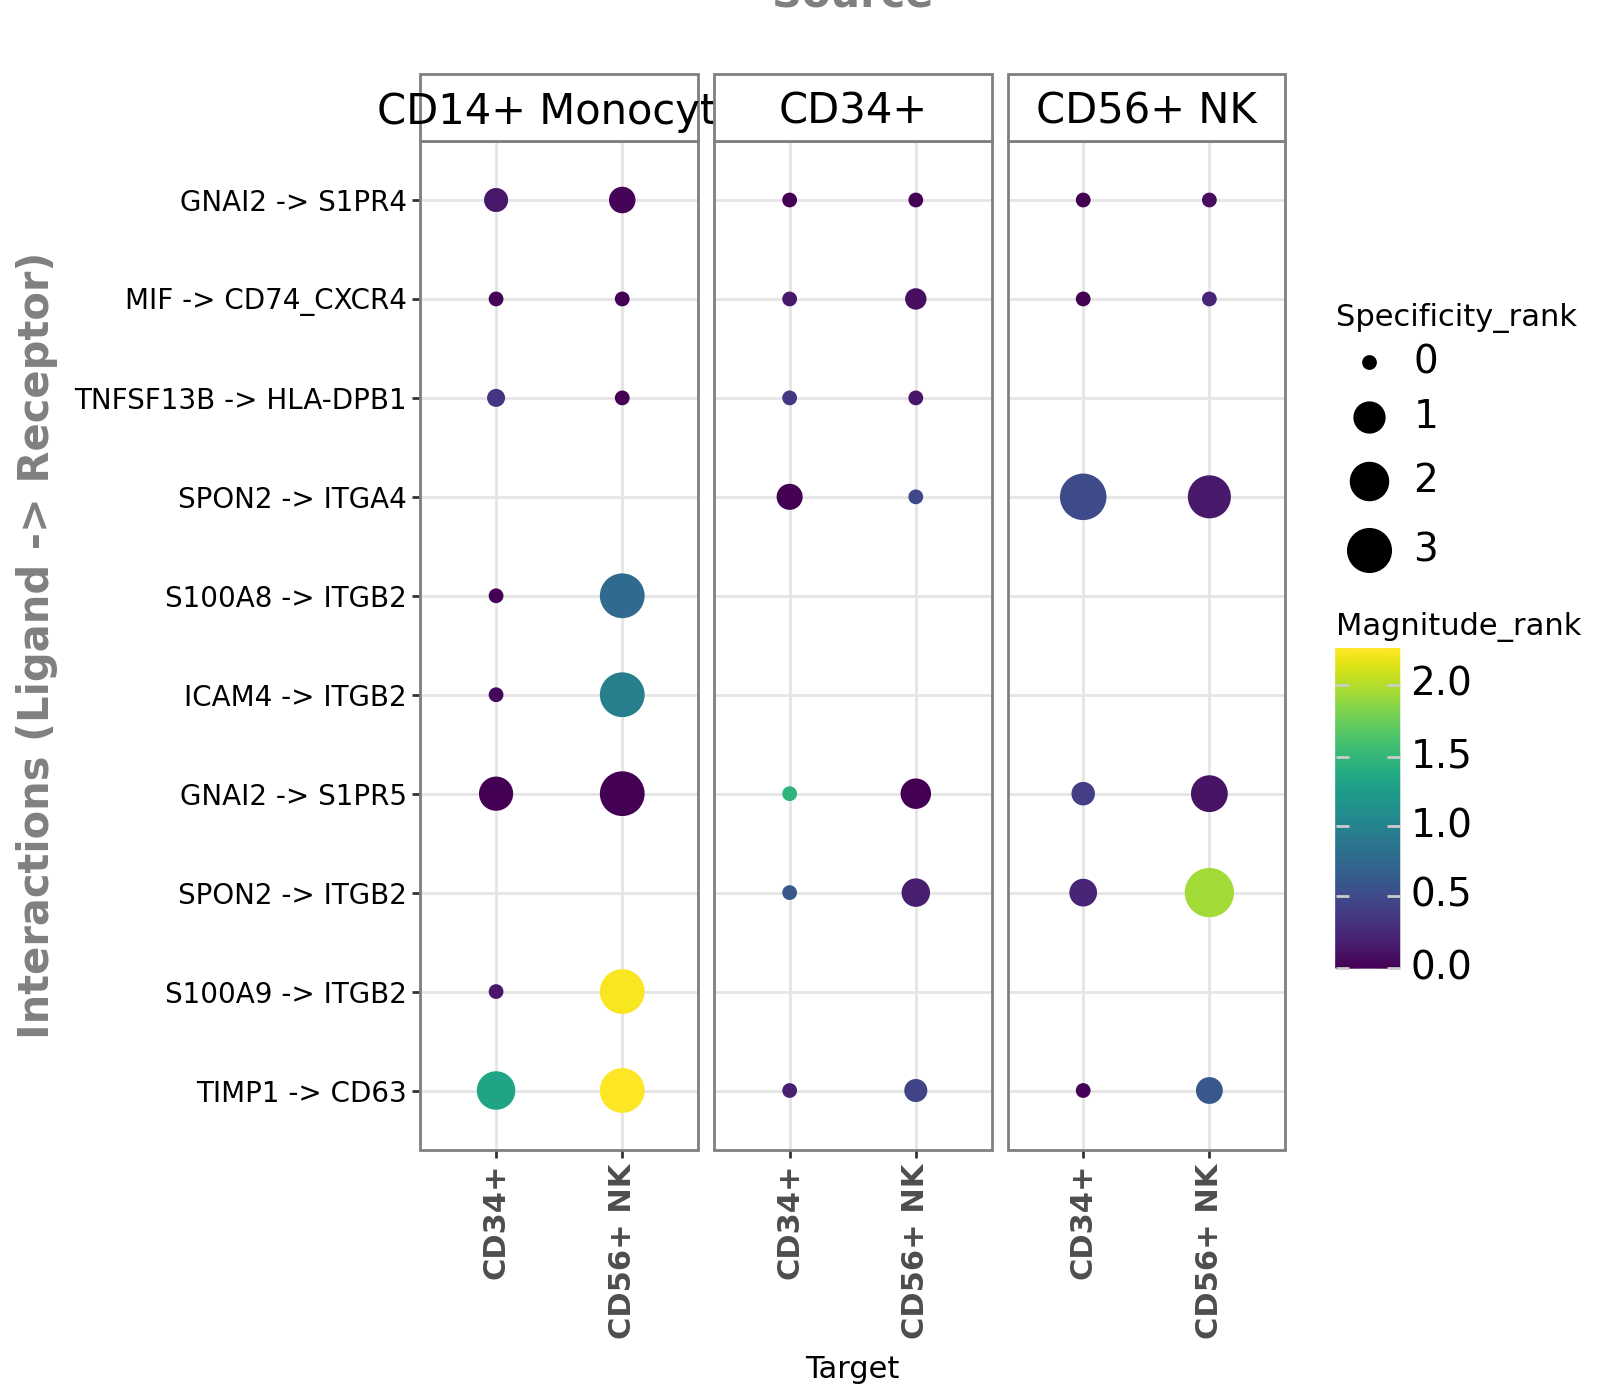

In [81]:
import warnings
import pandas as pd
pd.options.mode.chained_assignment = None  # suppress warning

li.pl.dotplot(
    adata          = adata,
    colour         = "magnitude_rank",
    size           = "specificity_rank",
    inverse_size   = True,
    inverse_colour = True,
    source_labels  = ["CD34+", "CD56+ NK", "CD14+ Monocyte"],
    target_labels  = ["CD34+", "CD56+ NK"],
    top_n          = 10,
    orderby        = "magnitude_rank",
    orderby_ascending = True,
    figure_size    = (8, 7)
)

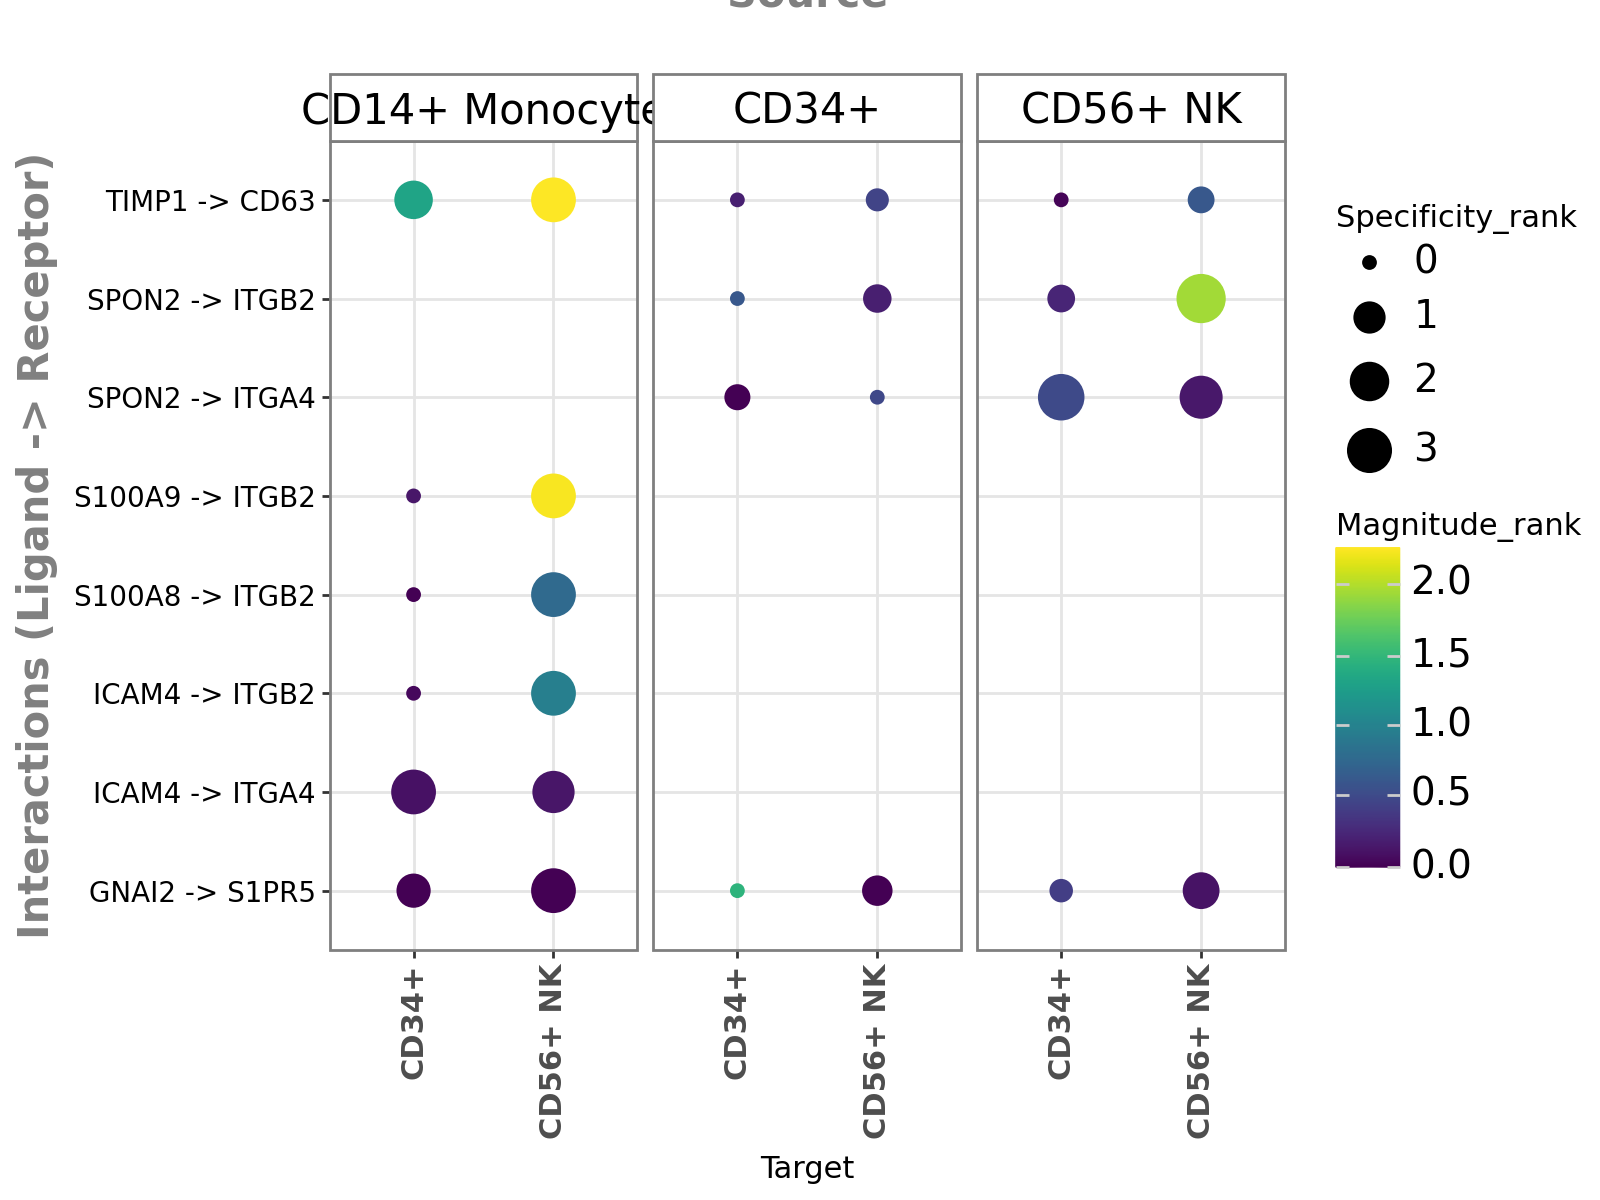

In [82]:
my_plot = li.pl.dotplot(adata = adata, 
                        colour = 'magnitude_rank',
                        inverse_colour = True,
                        size = 'specificity_rank',
                        inverse_size = True,
                        source_labels = ['CD34+', 'CD56+ NK', 'CD14+ Monocyte'],
                        target_labels = ['CD34+', 'CD56+ NK'],
                        filter_fun = lambda x: x['specificity_rank'] <= 0.01,
                       )
my_plot

In [ ]:
# my_plot.save('dotplot.pdf')

In [83]:
print("Circle Plot :")

Circle Plot :


<Axes: >

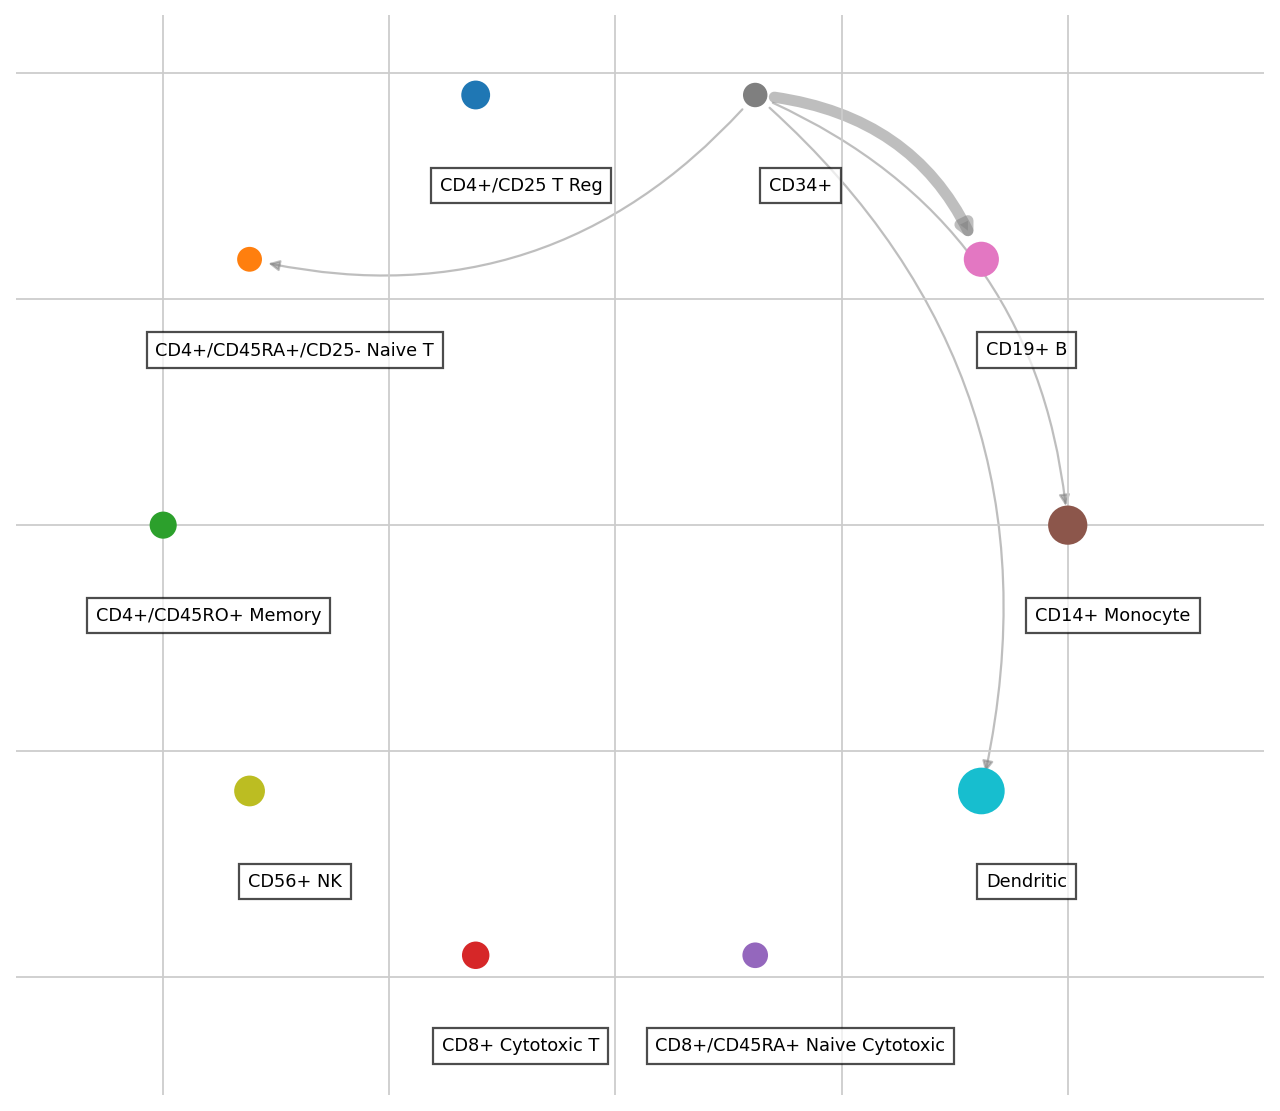

In [84]:
li.pl.circle_plot(adata,
                  groupby = 'bulk_labels',
                  score_key = 'magnitude_rank',
                  inverse_score = True,
                  source_labels = 'CD34+',
                  filter_fun = lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode = 'counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size = (10, 10),
                  )

In [85]:
print("Customizing LIANA’s RANK AGGREGATE : the user can choose to include only a subset of the methods")

Customizing LIANA’s RANK AGGREGATE : the user can choose to include only a subset of the methods


In [86]:
methods = [logfc, geometric_mean]
new_rank_aggregate = li.mt.AggregateClass(li.mt.aggregate_meta, methods=methods)

In [87]:
# Use key_added parameter to store the results ina  different SLOT : 

new_rank_aggregate(adata,
                   groupby = 'bulk_labels',
                   expr_prop = 0.1, 
                   verbose = True,
                   # Note that with this option, we don't perform permutations
                   # and hence we exclude the p-value for geometric_mean, as well as specificity_rank
                   n_perms = None,
                   use_raw = True,
                   key_added = "rank_agg_res"   # ← stored in adata.uns["rank_agg_res"]
                   )

2026-03-27 15:22:52 | [INFO] Using resource `consensus`.
2026-03-27 15:22:52 | [INFO] Using `.raw`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 15:22:52 | [INFO] 0.94 of entities in the resource are missing from the data.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:293: FutureWarning: Use uns (e.g. `k in adata.uns` or `sorted(adata.uns)`) instead of AnnData.uns_keys, AnnData.uns_keys is deprecated and will be removed in the future.
/home/tanasa/Desktop/LIA

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running log2FC
Running Geometric Mean


In [88]:
adata.uns['rank_agg_res'].head()

,source,target,ligand_complex,receptor_complex,lr_logfc,lr_gmeans,magnitude_rank
110,CD14+ Monocyte,CD56+ NK,TIMP1,CD63,1.435272,2.126363,0.000776
109,CD14+ Monocyte,CD56+ NK,S100A9,ITGB2,1.069681,2.048953,0.001553
20,CD14+ Monocyte,CD14+ Monocyte,S100A9,ITGB2,1.069747,1.979752,0.002329
838,CD56+ NK,CD56+ NK,SPON2,ITGB2,1.860055,1.926317,0.003106
782,CD56+ NK,CD14+ Monocyte,SPON2,ITGB2,1.860121,1.861258,0.003882


In [89]:
from liana.method import rank_aggregate

rank_aggregate(
    adata,
    groupby       = "bulk_labels",
    expr_prop     = 0.1,
    verbose       = True,
    n_perms       = None,
    use_raw       = True,
    key_added     = "rank_agg_res"   # ← stored in adata.uns["rank_agg_res"]
)

# access results
print(adata.uns["rank_agg_res"].head())

2026-03-27 15:22:59 | [INFO] Using resource `consensus`.
2026-03-27 15:22:59 | [INFO] Using `.raw`!
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
2026-03-27 15:22:59 | [INFO] 0.94 of entities in the resource are missing from the data.
/home/tanasa/anaconda3/lib/python3.12/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
/home/tanasa/Desktop/LIANA/liana_env/lib/python3.12/site-packages/liana/method/sc/_liana_pipe.py:288: ImplicitModificationWarning: Setting element `.layers['scaled']` of v

Generating ligand-receptor stats for 700 samples and 43 features
Assuming that counts were `natural` log-normalized!
Running CellPhoneDB
Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR
         source                      target ligand_complex receptor_complex  \
1209  Dendritic         CD4+/CD45RO+ Memory        HLA-DRA              CD4   
1188  Dendritic  CD4+/CD45RA+/CD25- Naive T        HLA-DRA              CD4   
1210  Dendritic         CD4+/CD45RO+ Memory       HLA-DRB1              CD4   
1205  Dendritic         CD4+/CD45RO+ Memory       HLA-DPB1              CD4   
1189  Dendritic  CD4+/CD45RA+/CD25- Naive T       HLA-DRB1              CD4   

      lr_means  expr_prod  scaled_weight  lr_logfc  spec_weight   lrscore  \
1209  2.575263   2.780884       0.723815  1.431303     0.065077  0.736772   
1188  2.566905   2.705027       0.709428  1.332656     0.063302  0.734081   
1210  2.415010   2.584465       0.712731  1.331341     0.060203  0.729607   
1205  

In [90]:
print('''

What is the TRI-MEAN ?

👉 The trimean is a robust measure of central tendency that combines:

* median
* lower quartile (Q1)
* upper quartile (Q3)

import numpy as np

def trimean(x):
    q1     = np.percentile(x, 25)
    median = np.percentile(x, 50)
    q3     = np.percentile(x, 75)
    return (q1 + 2 * median + q3) / 4

Interpretation
Gives 50% weight to the median
Gives 25% weight to Q1
Gives 25% weight to Q3

''')



What is the TRI-MEAN ?

👉 The trimean is a robust measure of central tendency that combines:

* median
* lower quartile (Q1)
* upper quartile (Q3)

import numpy as np

def trimean(x):
    q1     = np.percentile(x, 25)
    median = np.percentile(x, 50)
    q3     = np.percentile(x, 75)
    return (q1 + 2 * median + q3) / 4

Interpretation
Gives 50% weight to the median
Gives 25% weight to Q1
Gives 25% weight to Q3




In [ ]:
print('''

Trimean = a robust average combining median and quartiles, used to stabilize gene expression estimates in noisy single-cell data.

| Metric      | Behavior                       |
| ----------- | ------------------------------ |
| Mean        | sensitive to outliers          |
| Median      | ignores distribution shape     |
| **Trimean** | robust + still reflects spread |

''')

In [91]:
# https://liana-py.readthedocs.io/en/latest/notebooks/basic_usage.html

# | Method                          | Magnitude (Interaction Strength)                                                       | Specificity              |
# | ------------------------------- | -------------------------------------------------------------------------------------- | ------------------------ |
# | **CellPhoneDB v2**              | ( LRmean_{k,i,j} = \frac{L_{c_i} + R_{c_j}}{2} )                                       | See permutation p-values |
# | **Geometric Mean**              | ( LR_{geometric.mean_{k,i,j}} = \sqrt{L_{c_i} \cdot R_{c_j}} )                         | See permutation p-values |
# | **CellChat (LR probabilities)** | ( LRprob_{k,i,j} = \frac{L^*_{c_i} \cdot R^**{c_j}}{K_h + L^**{c_i} \cdot R^*_{c_j}} ) | See permutation p-values |

print('''

CellChat computes interaction probability as:

def cellchat_prob(L_star, R_star, Kh=0.5):
    numerator   = L_star * R_star
    denominator = Kh + L_star * R_star
    return numerator / denominator

Where:

L∗ = trimean expression of the ligand in the source cell type
R∗ = trimean expression of the receptor in the target cell type
Kh​ = Hill normalization constant (default = 0.5)

This is a Hill function — it saturates at 1 when expression is very high, and approaches 0 when expression is low. 

The Kh​ constant controls the steepness of the curve.

''')



CellChat computes interaction probability as:

def cellchat_prob(L_star, R_star, Kh=0.5):
    numerator   = L_star * R_star
    denominator = Kh + L_star * R_star
    return numerator / denominator

Where:

L∗ = trimean expression of the ligand in the source cell type
R∗ = trimean expression of the receptor in the target cell type
Kh​ = Hill normalization constant (default = 0.5)

This is a Hill function — it saturates at 1 when expression is very high, and approaches 0 when expression is low. 

The Kh​ constant controls the steepness of the curve.




In [92]:
print('''

Geometric mean = a generic scoring strategy used across multiple tools (and standardized in LIANA)

NATMI (closest association) : L × R   (product)

Connectome : also uses L x R

LIANA includes geometric mean as a standardized metric.
      
LIANA’s Consensus : 

Used flexibly to combine the Magnitude scores of the methods above. By default, uses all except the Geometric mean and CellChat, 
independently for magnitude and specificity scores.

The RobustRankAggregate method expresses the probability rnull(k)<= r(k) as k,n(r) through a beta distribution.

Why CellChat uses trimean: 

| Issue                      | What trimean does                |
| -------------------------- | -------------------------------- |
| Dropouts (zeros)           | reduces impact                   |
| Outliers (very high cells) | dampens them                     |
| Heterogeneity              | captures central tendency better |


| Method             | Expression summary   |
| ------------------ | -------------------- |
| CellPhoneDB        | mean                 |
| NATMI / Connectome | product of means     |
| **CellChat**       | **trimean (robust)** |

''')



Geometric mean = a generic scoring strategy used across multiple tools (and standardized in LIANA)

NATMI (closest association) : L × R   (product)

Connectome : also uses L x R

LIANA includes geometric mean as a standardized metric.

LIANA’s Consensus : 

Used flexibly to combine the Magnitude scores of the methods above. By default, uses all except the Geometric mean and CellChat, 
independently for magnitude and specificity scores.

The RobustRankAggregate method expresses the probability rnull(k)<= r(k) as k,n(r) through a beta distribution.

Why CellChat uses trimean: 

| Issue                      | What trimean does                |
| -------------------------- | -------------------------------- |
| Dropouts (zeros)           | reduces impact                   |
| Outliers (very high cells) | dampens them                     |
| Heterogeneity              | captures central tendency better |


| Method             | Expression summary   |
| ------------------ | --------------

In [93]:
li.rs.describe_metalinks()

Schema of table: metabolites
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: metabolite, Type: TEXT, Primary Key: 0
Column ID: 2, Name: pubchem, Type: TEXT, Primary Key: 0
Column ID: 3, Name: metabolite_subclass, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: proteins
Column ID: 0, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 1, Name: gene_symbol, Type: TEXT, Primary Key: 0
Column ID: 2, Name: protein_type, Type: TEXT, Primary Key: 0

No Foreign Keys.
----------------------------------------
Schema of table: edges
Column ID: 0, Name: hmdb, Type: TEXT, Primary Key: 0
Column ID: 1, Name: uniprot, Type: TEXT, Primary Key: 0
Column ID: 2, Name: source, Type: TEXT, Primary Key: 0
Column ID: 3, Name: db_score, Type: REAL, Primary Key: 0
Column ID: 4, Name: experiment_score, Type: REAL, Primary Key: 0
Column ID: 5, Name: combined_score, Type: REAL, Primary Key: 0
Column ID: 6, Name: mor, Type: INTEGER, Pr

In [94]:
print(''' Annotating Ligand-Receptors :

We use commonly PROGENy pathway weights ;

Disease Annotations : 'DisGeNet' ;

Enrichment score : Decoupler : https://decoupler.readthedocs.io/en/latest/

Intracellular Signaling : a protein-protein interaction network ;

Transcription Factor Regulons ;

Metabolite-Receptor Interaction.

''')

 Annotating Ligand-Receptors :

We use commonly PROGENy pathway weights ;

Disease Annotations : 'DisGeNet' ;

Enrichment score : Decoupler : https://decoupler.readthedocs.io/en/latest/

Intracellular Signaling : a protein-protein interaction network ;

Transcription Factor Regulons ;

Metabolite-Receptor Interaction.




In [95]:
# This returns a combined DataFrame filtered by:
# source ∈ {Stich, CellPhoneDB, NeuronChat}
# tissue = Brain

res = li.resource.get_metalinks(
    source=['Stich', 'CellPhoneDB', 'NeuronChat'],
    tissue_location='Brain'
)

res_neuronchat = res[res['source'] == 'NeuronChat']

res_neuronchat.head()
res_neuronchat.shape
res_neuronchat.tail()

,hmdb,uniprot,gene_symbol,metabolite,mor,transport_direction,type,source
269,HMDB0000112,P47869,GABRA2,gamma-Aminobutyric acid,1,None,lr,NeuronChat
271,HMDB0000112,P47870,GABRB2,gamma-Aminobutyric acid,1,None,lr,NeuronChat
273,HMDB0000112,P48169,GABRA4,gamma-Aminobutyric acid,1,None,lr,NeuronChat
278,HMDB0000112,Q9UBS5,GABBR1,gamma-Aminobutyric acid,0,None,lr,NeuronChat
279,HMDB0000112,Q9UBS5,GABBR1,gamma-Aminobutyric acid,1,None,lr,NeuronChat
